# Modelo Multimodal con Transfer Learning (ImageNet)

Este cuaderno implementa la experimentación con el modelo **MTDE-Net** utilizando **Transfer Learning** basado en backbones convolucionales preentrenados en **ImageNet** (ResNet-18 y ResNet-50).

### Enfoque Científico del Experimento:
* Las imágenes térmicas son canal único (escala de grises), por lo que se expanden a 3 canales en la primera capa convolucional de manera implícita para conservar el 100% de los pesos preentrenados de ImageNet.
* Evaluamos tres configuraciones de entrenamiento:
  1. **ResNet-18 con Fine-tuning completo** (backbone preentrenado sintonizado con learning rate bajo).
  2. **ResNet-18 con Backbone Congelado** (usado puramente como extractor de características estáticas).
  3. **ResNet-50 con Fine-tuning completo** (backbone de mayor capacidad no lineal).

Al final, se comparan las métricas obtenidas con las del MTDE-Net original sin preentrenar.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.models.mtde_net_tl import MTDE_Net_TL
from src.loaders.mtde_net_loader import MultimodalThermalDataset
from src.utils import SqrtScaledMSELoss, eval_mtde_net_metrics, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window, build_subject_split_plan

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del Dataset y Partición Estricta por Secuencias

In [3]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
time_scale = 30.0
metadata_path = "../processed_data/metadata_train.csv"

train_ds_full = MultimodalThermalDataset(
    metadata_csv=metadata_path, 
    is_train=True, 
    min_time_s=0.0,
    time_scale=time_scale
)
val_ds_full = MultimodalThermalDataset(
    metadata_csv=metadata_path, 
    is_train=False, 
    min_time_s=0.0,
    time_scale=time_scale
)
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

plan = build_subject_split_plan(
    train_ds_full.df,
    n_splits=9,
    seed=42,
    test_subjects=["tania", "matias"],
    reserve_incomplete_for_test=True
)

print("=== PLAN DE PARTICIÓN CONFIGURADO (LOSO 9 FOLDS) ===")
print(f"Sujetos de Test Fijo ({plan.num_test_subjects}): {plan.test_subjects} ({plan.num_test_samples} muestras)")
print(f"Sujetos para Train-Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} ({plan.num_trainval_samples} muestras)")

=== PLAN DE PARTICIÓN CONFIGURADO (LOSO 9 FOLDS) ===
Sujetos de Test Fijo (3): ['eduardo', 'matias', 'tania'] (607 muestras)
Sujetos para Train-Val (9): ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin'] (2514 muestras)


### 3. Función Genérica de Entrenamiento y Evaluación

In [4]:
def train_and_evaluate(backbone_name, pretrained, freeze_backbone, lr, epochs=30, batch_size=16, patience=8):
    set_seed(42)
    
    fold_metrics = []
    print(f"\n>>> Entrenando {backbone_name.upper()} | Pretrained: {pretrained} | Freeze: {freeze_backbone} | lr: {lr}")
    
    # 1. VALIDACIÓN CRUZADA DE 9 FOLDS (LOSO)
    for fold in plan.folds:
        train_ds = MultimodalThermalDataset(
            metadata_csv=metadata_path,
            is_train=True,
            min_time_s=0.0,
            time_scale=time_scale,
            indices=fold.train_indices
        )
        val_ds = MultimodalThermalDataset(
            metadata_csv=metadata_path,
            is_train=False,
            min_time_s=0.0,
            time_scale=time_scale,
            indices=fold.val_indices,
            means=train_ds.means,
            stds=train_ds.stds
        )
        train_ds.root = Path("../processed_data")
        val_ds.root = Path("../processed_data")
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)
        
        model = MTDE_Net_TL(
            backbone_name=backbone_name,
            pretrained=pretrained,
            freeze_backbone=freeze_backbone,
            tabular_dim=4,
            dropout=0.2
        ).to(dev)
        
        crit = SqrtScaledMSELoss(scale=time_scale)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        
        best_fold_mae = float("inf")
        best_metrics = None
        patience_counter = 0
        history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
        
        for ep in range(1, epochs + 1):
            model.train()
            train_loss = 0.0
            train_n = 0
            for x_img, x_tab, y in train_loader:
                x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
                opt.zero_grad(set_to_none=True)
                loss = crit(model(x_img, x_tab), y)
                loss.backward()
                opt.step()
                train_loss += loss.item() * x_img.size(0)
                train_n += x_img.size(0)
                
            model.eval()
            val_loss = 0.0
            val_n = 0
            with torch.no_grad():
                for val_x_img, val_x_tab, val_y in val_loader:
                    val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
                    loss = crit(model(val_x_img, val_x_tab), val_y)
                    val_loss += loss.item() * val_x_img.size(0)
                    val_n += val_x_img.size(0)
            
            val_m = eval_mtde_net_metrics(model, val_loader, dev, scale=time_scale)
            train_m = eval_mtde_net_metrics(model, train_loader, dev, scale=time_scale)
            v_mae = val_m["mae"]
            
            history["train_loss"].append(train_loss / train_n)
            history["val_loss"].append(val_loss / val_n)
            history["train_mae"].append(train_m["mae"])
            history["val_mae"].append(v_mae)
            
            if v_mae < best_fold_mae - 0.5:
                best_fold_mae = v_mae
                best_metrics = val_m
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                break
                
        fold_metrics.append(best_metrics)
        
    df_folds = pd.DataFrame(fold_metrics)
    print(f"\n--- Resumen de Validación Cruzada (9 Folds) ---")
    print(df_folds.mean().to_frame("CV Mean").join(df_folds.std().to_frame("CV Std")))
    
    # 2. ENTRENAMIENTO FINAL Y EVALUACIÓN EN TEST
    print(f"\n--- Entrenando modelo final en todo Train-Val ---")
    trainval_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path,
        is_train=True,
        min_time_s=0.0,
        time_scale=time_scale,
        indices=plan.trainval_indices
    )
    test_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path,
        is_train=False,
        min_time_s=0.0,
        time_scale=time_scale,
        indices=plan.test_indices,
        means=trainval_ds.means,
        stds=trainval_ds.stds
    )
    trainval_ds.root = Path("../processed_data")
    test_ds.root = Path("../processed_data")
    
    trainval_loader = DataLoader(trainval_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)
    
    model_final = MTDE_Net_TL(
        backbone_name=backbone_name,
        pretrained=pretrained,
        freeze_backbone=freeze_backbone,
        tabular_dim=4,
        dropout=0.2
    ).to(dev)
    
    crit = SqrtScaledMSELoss(scale=time_scale)
    opt = torch.optim.AdamW(model_final.parameters(), lr=lr, weight_decay=1e-4)
    
    epochs_final = 30  # Entrenar por 30 épocas en el conjunto completo
    for ep in range(1, epochs_final + 1):
        model_final.train()
        for x_img, x_tab, y in trainval_loader:
            x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model_final(x_img, x_tab), y)
            loss.backward()
            opt.step()
            
    # Guardar modelo final
    dest_path = Path(f"../models/MTDE_Net_TL_{backbone_name}_{'congelado' if freeze_backbone else 'finetuned'}.pt")
    torch.save(model_final.state_dict(), dest_path)
    
    # Evaluar en Test
    test_metrics = eval_mtde_net_metrics(model_final, test_loader, dev, scale=time_scale)
    print(f"\n=== Resultados Finales en Test Set (Tania, Matias, Eduardo) ===")
    for k, v in test_metrics.items():
        print(f"  {k.upper()}: {v:.4f}")
        
    # Visualizaciones
    model_final.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_img, x_tab, y in test_loader:
            x_img, x_tab = x_img.to(dev), x_tab.to(dev)
            p = model_final(x_img, x_tab)
            all_preds.extend(p.cpu().numpy() * time_scale)
            all_targets.extend(y.numpy() * time_scale)
            
    # Graficar curvas de aprendizaje del último fold
    plot_learning_curves(history)
    
    # Graficar calibración y error
    plot_prediction_calibration(np.array(all_targets), np.array(all_preds), model_name=f"MTDE-Net TL {backbone_name.upper()}")
    plot_error_by_time_window(np.array(all_targets), np.array(all_preds), model_name=f"MTDE-Net TL {backbone_name.upper()}")
    
    return test_metrics


### 4. Experimento 1: ResNet-18 Preentrenado + Fine-tuning completo


>>> Entrenando RESNET18 | Pretrained: True | Freeze: False | lr: 0.0002

--- Resumen de Validación Cruzada (9 Folds) ---
          CV Mean     CV Std
mae     29.127044   9.857176
rmse    44.372825  17.257040
r2       0.916007   0.075799
mape    26.495128   8.480372
acc60   86.574477   6.108129
acc120  97.111200   4.100174

--- Entrenando modelo final en todo Train-Val ---

=== Resultados Finales en Test Set (Tania, Matias, Eduardo) ===
  MAE: 41.7677
  RMSE: 62.3530
  R2: 0.8534
  MAPE: 37.5414
  ACC60: 75.2883
  ACC120: 93.0807


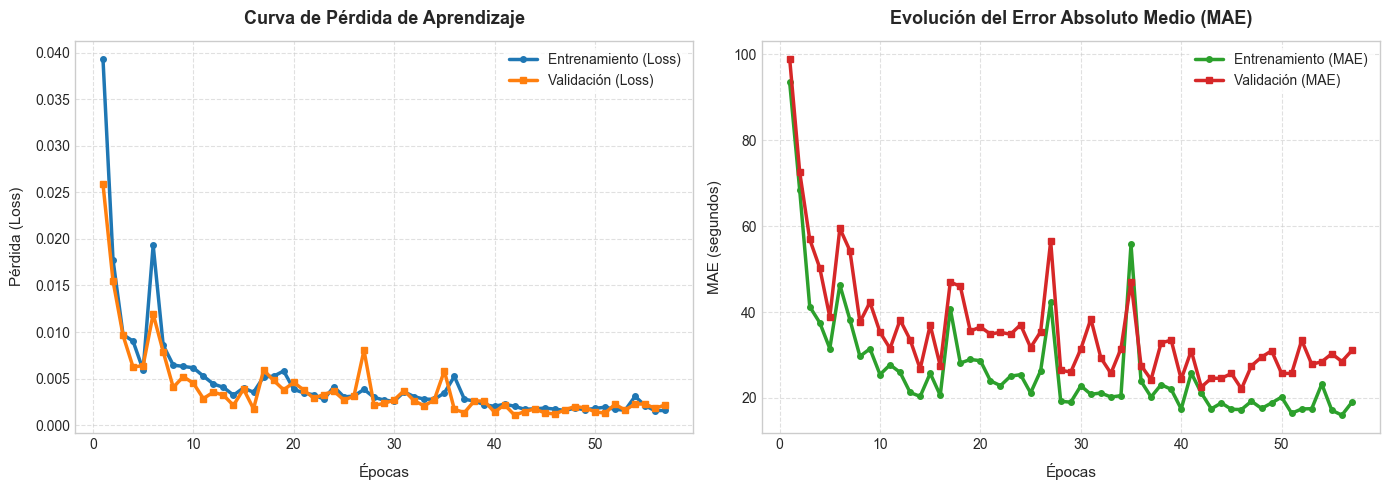

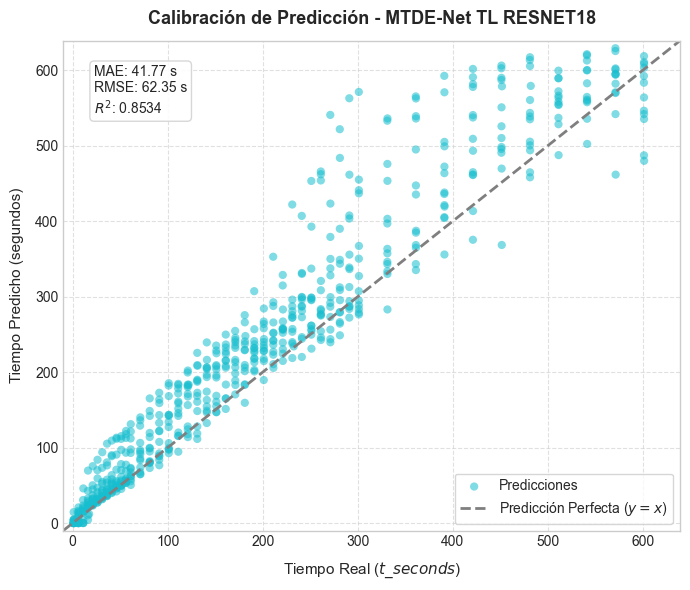

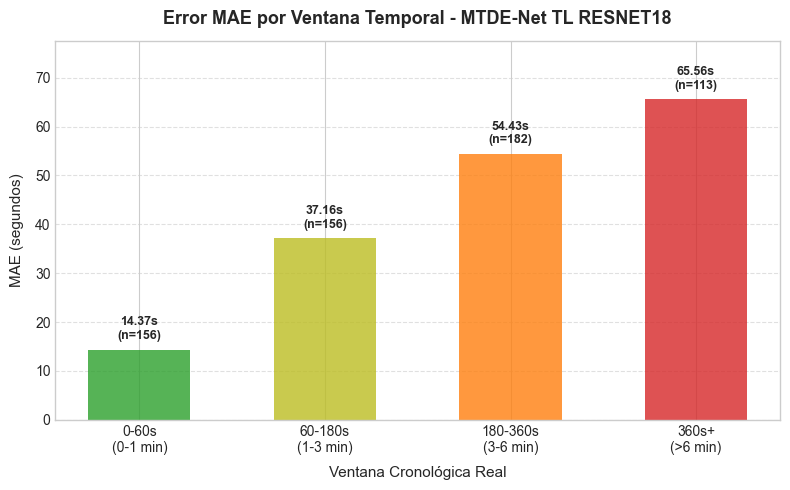

In [5]:
# Fine-tuning completo con una lr baja de 2e-4
m_r18_ft = train_and_evaluate(
    backbone_name="resnet18", 
    pretrained=True, 
    freeze_backbone=False, 
    lr=2e-4, 
    epochs=120, 
    batch_size=16,
    patience=15
)

### 5. Experimento 2: ResNet-18 Congelado (Feature Extractor estático)


>>> Entrenando RESNET18 | Pretrained: True | Freeze: True | lr: 0.0005

--- Resumen de Validación Cruzada (9 Folds) ---
          CV Mean     CV Std
mae     59.798524  19.147932
rmse    85.449258  17.289283
r2       0.714317   0.122339
mape    98.129729  61.245233
acc60   64.788873  14.828068
acc120  84.419562  10.358403

--- Entrenando modelo final en todo Train-Val ---

=== Resultados Finales en Test Set (Tania, Matias, Eduardo) ===
  MAE: 67.1333
  RMSE: 93.8164
  R2: 0.6682
  MAPE: 82.6972
  ACC60: 57.9901
  ACC120: 81.5486


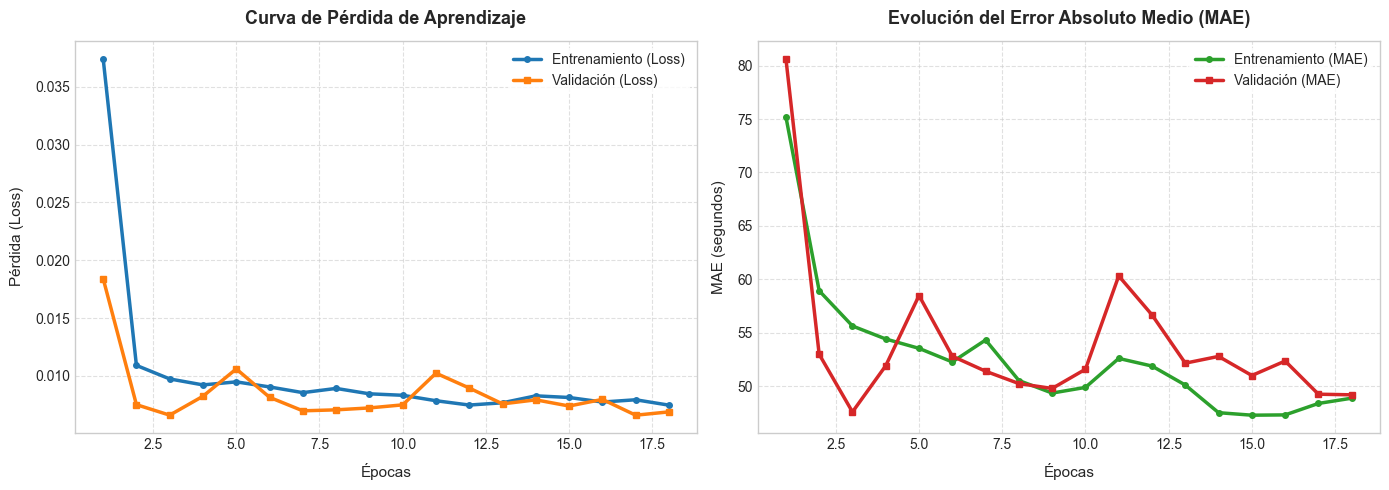

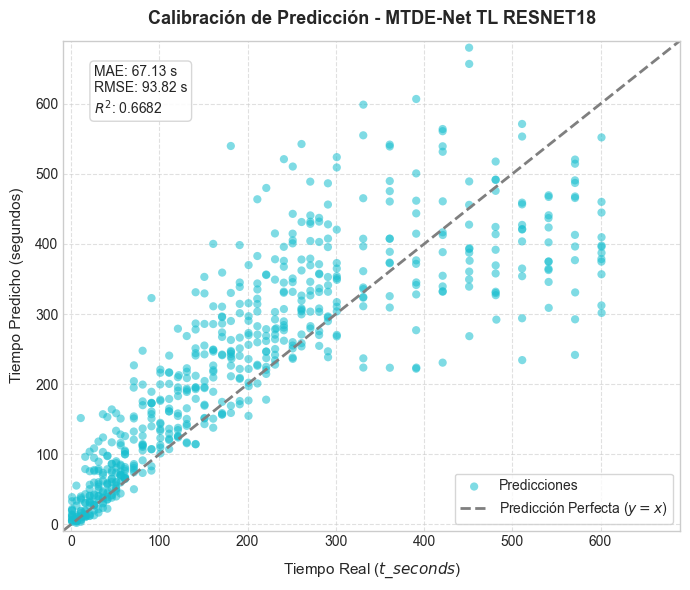

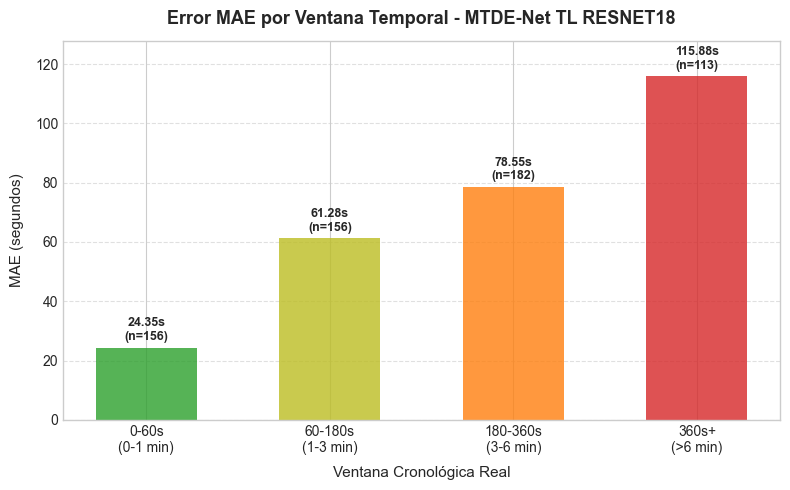

In [6]:
# Backbone congelado, se puede usar una lr un poco mayor (5e-4) para el cabezal
m_r18_frozen = train_and_evaluate(
    backbone_name="resnet18", 
    pretrained=True, 
    freeze_backbone=True, 
    lr=5e-4, 
    epochs=120, 
    batch_size=16,
    patience=15
)

### 6. Experimento 3: ResNet-50 Preentrenado + Fine-tuning completo


>>> Entrenando RESNET50 | Pretrained: True | Freeze: False | lr: 0.0001

--- Resumen de Validación Cruzada (9 Folds) ---
          CV Mean     CV Std
mae     31.673973  10.343628
rmse    47.162367  14.637511
r2       0.908956   0.063018
mape    27.922844   8.741854
acc60   84.948481   7.621383
acc120  96.354197   3.327414

--- Entrenando modelo final en todo Train-Val ---

=== Resultados Finales en Test Set (Tania, Matias, Eduardo) ===
  MAE: 36.6016
  RMSE: 54.8006
  R2: 0.8868
  MAPE: 32.3398
  ACC60: 81.7133
  ACC120: 94.0692


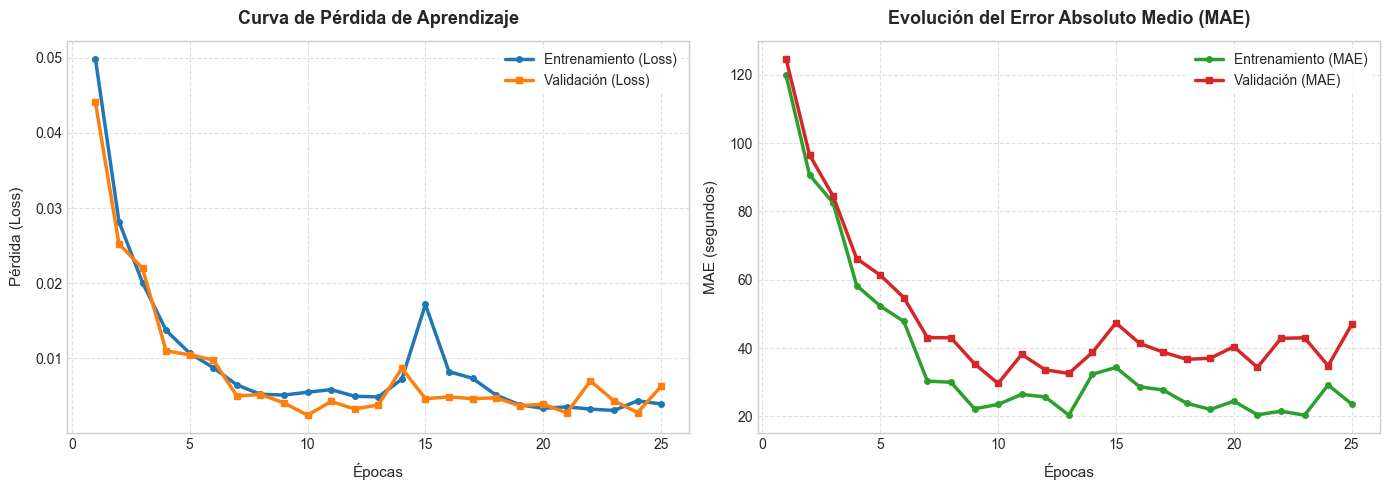

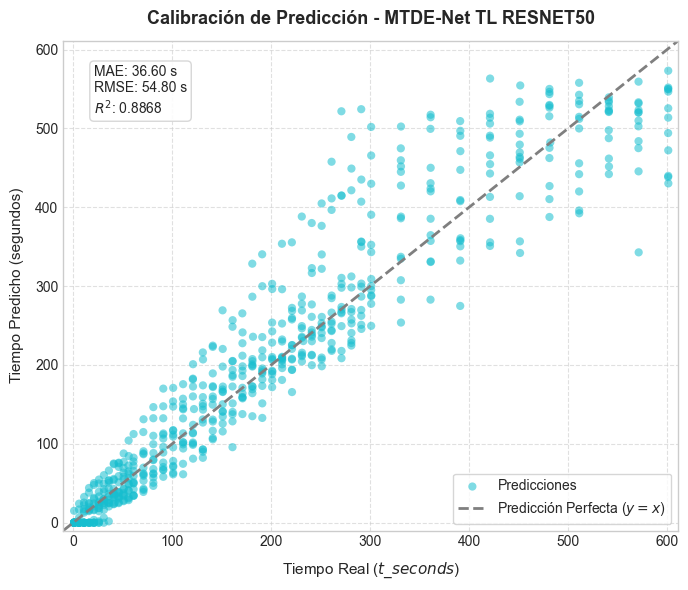

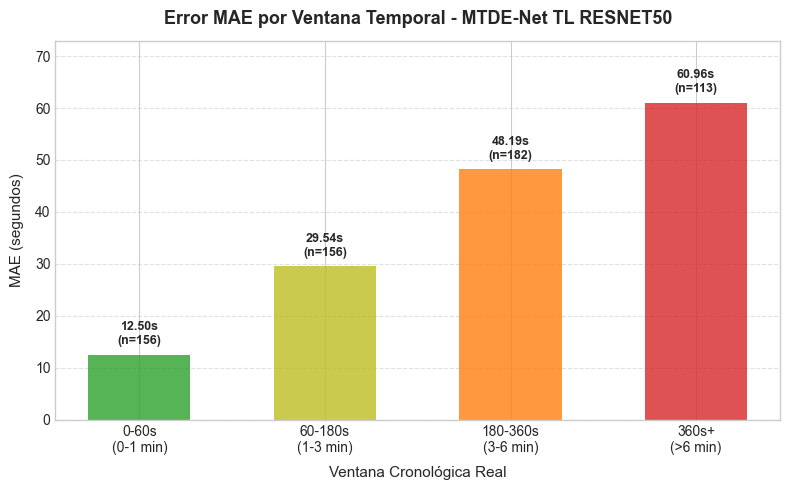

In [7]:
# ResNet-50 es más expresivo y denso. Usamos una lr controlada de 1e-4
m_r50_ft = train_and_evaluate(
    backbone_name="resnet50", 
    pretrained=True, 
    freeze_backbone=False, 
    lr=1e-4, 
    epochs=120, 
    batch_size=16,
    patience=15
)

### 7. Resumen y Comparación de Resultados Experimentales

In [8]:
results_data = []

if m_r18_ft:
    results_data.append({
        "Configuración": "ResNet-18 Fine-tuned (ImageNet)",
        "MAE (s)": f"{m_r18_ft['mae']:.2f} s",
        "RMSE (s)": f"{m_r18_ft['rmse']:.2f} s",
        "R²": f"{m_r18_ft['r2']:.4f}",
        "MAPE (%)": f"{m_r18_ft['mape']:.2f} %",
        "Acc@60s (%)": f"{m_r18_ft['acc60']:.2f} %",
        "Acc@120s (%)": f"{m_r18_ft['acc120']:.2f} %"
    })
if m_r18_frozen:
    results_data.append({
        "Configuración": "ResNet-18 Frozen (FE)",
        "MAE (s)": f"{m_r18_frozen['mae']:.2f} s",
        "RMSE (s)": f"{m_r18_frozen['rmse']:.2f} s",
        "R²": f"{m_r18_frozen['r2']:.4f}",
        "MAPE (%)": f"{m_r18_frozen['mape']:.2f} %",
        "Acc@60s (%)": f"{m_r18_frozen['acc60']:.2f} %",
        "Acc@120s (%)": f"{m_r18_frozen['acc120']:.2f} %"
    })
if m_r50_ft:
    results_data.append({
        "Configuración": "ResNet-50 Fine-tuned (ImageNet)",
        "MAE (s)": f"{m_r50_ft['mae']:.2f} s",
        "RMSE (s)": f"{m_r50_ft['rmse']:.2f} s",
        "R²": f"{m_r50_ft['r2']:.4f}",
        "MAPE (%)": f"{m_r50_ft['mape']:.2f} %",
        "Acc@60s (%)": f"{m_r50_ft['acc60']:.2f} %",
        "Acc@120s (%)": f"{m_r50_ft['acc120']:.2f} %"
    })

df_res = pd.DataFrame(results_data)
print("\n=== RESUMEN COMPARATIVO DE TRANSFER LEARNING ===")
display(df_res)


=== RESUMEN COMPARATIVO DE TRANSFER LEARNING ===


,Configuración,MAE (s),RMSE (s),R²,MAPE (%),Acc@60s (%),Acc@120s (%)
0,ResNet-18 Fine-tuned (ImageNet),41.77 s,62.35 s,0.8534,37.54 %,75.29 %,93.08 %
1,ResNet-18 Frozen (FE),67.13 s,93.82 s,0.6682,82.70 %,57.99 %,81.55 %
2,ResNet-50 Fine-tuned (ImageNet),36.60 s,54.80 s,0.8868,32.34 %,81.71 %,94.07 %
